Alumno: Jesus Montserrat Zaragoza Carrillo

Proyecto: Predicción del Precio de Venta de Productos

Descripción del dataset:
Se cuenta con un dataset simulado que contiene 13 columnas:

| Columna           | Descripción                                                                                    |
| ----------------- | ---------------------------------------------------------------------------------------------- |
| `id`              | Identificador único de cada transacción. No contiene información relevante para la predicción. |
| `sales_price`     | Valor al que se vendió el producto. **Variable objetivo**.                                     |
| `production_cost` | Costo de producción del producto.                                                              |
| `date`            | Fecha y hora de la transacción.                                                                |
| `difficult_ind`   | Indicador de si la carga es difícil.                                                           |
| `size`            | Tamaño del producto.                                                                           |
| `geographic_zone` | Zona geográfica donde se realizó la venta.                                                     |
| `cat_fet_1`       | Variable categórica genérica que diferencia productos.                                         |
| `cat_fet_2`       | Variable categórica genérica que diferencia productos.                                         |
| `cat_fet_3`       | Variable categórica genérica que diferencia productos.                                         |
| `cat_fet_4`       | Variable categórica genérica que diferencia productos.                                         |
| `time_remaining`  | Tiempo restante antes de que el producto caduque.                                              |
| `market_index`    | Comportamiento del mercado para la región y producto en ese momento.                           |



### Objetivo

Desarrollar un modelo predictivo para predecir el precio de venta (sales_price) utilizando las demás variables como características.

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
import statsmodels.api as sm

from scipy import stats

import itertools

%matplotlib inline

import numpy as np

from sklearn.model_selection import train_test_split
# Calcular métricas de error
from sklearn.metrics import mean_squared_error, r2_score


In [123]:
df=pd.read_csv("interview_data.csv") # Leer el archivo 

df

,id,sales_price,production_cost,date,difficult_ind,size,geographic_zone,cat_fet_1,cat_fet_2,cat_fet_3,cat_fet_4,time_remaining,market_index
0,23068,75.00,75.00,2022-11-03 15:00:00,False,52.14,Z4,B,A,A,B,28.75,10.94
1,56557,58.33,58.33,2022-11-14 13:30:00,False,39.14,Z4,B,A,A,A,75.20,2.25
2,91446,41.67,47.20,2022-11-22 12:00:00,False,3.71,Z4,B,A,A,A,1.44,2.62
3,91480,41.67,47.26,2022-11-22 10:30:00,False,3.71,Z4,B,A,A,A,1.01,2.62
4,94765,125.00,111.43,2022-11-27 10:00:00,False,60.57,Z3,B,A,A,A,1.31,5.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...
297524,497536,233.33,245.42,2023-03-27 15:30:00,False,287.57,Z9,B,A,A,A,4.03,1.78
297525,500241,208.33,245.25,2023-03-28 13:00:00,False,152.14,Z4,B,A,A,A,5.79,7.07
297526,497293,175.00,183.33,2023-03-28 13:00:00,False,170.00,Z1,B,A,A,B,24.90,1.25
297527,477281,50.00,49.83,2023-03-27 12:00:00,False,35.86,Z2,B,B,A,B,97.08,3.89


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297529 entries, 0 to 297528
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               297529 non-null  int64  
 1   sales_price      297529 non-null  float64
 2   production_cost  297529 non-null  float64
 3   date             297529 non-null  object 
 4   difficult_ind    297529 non-null  bool   
 5   size             297529 non-null  float64
 6   geographic_zone  297523 non-null  object 
 7   cat_fet_1        297529 non-null  object 
 8   cat_fet_2        297529 non-null  object 
 9   cat_fet_3        297529 non-null  object 
 10  cat_fet_4        297529 non-null  object 
 11  time_remaining   297529 non-null  float64
 12  market_index     297529 non-null  float64
dtypes: bool(1), float64(5), int64(1), object(6)
memory usage: 27.5+ MB


In [125]:
df_corr = df.corr(numeric_only=True)
df_corr

,id,sales_price,production_cost,difficult_ind,size,time_remaining,market_index
id,1.000000,-0.062607,-0.066223,-0.050640,0.010337,-0.015074,0.021566
sales_price,-0.062607,1.000000,0.958241,0.131782,0.894713,-0.037227,0.065862
production_cost,-0.066223,0.958241,1.000000,0.053484,0.878912,0.009778,0.047407
difficult_ind,-0.050640,0.131782,0.053484,1.000000,0.049416,-0.085700,0.062790
size,0.010337,0.894713,0.878912,0.049416,1.000000,-0.024392,-0.007268
time_remaining,-0.015074,-0.037227,0.009778,-0.085700,-0.024392,1.000000,-0.038261
market_index,0.021566,0.065862,0.047407,0.062790,-0.007268,-0.038261,1.000000


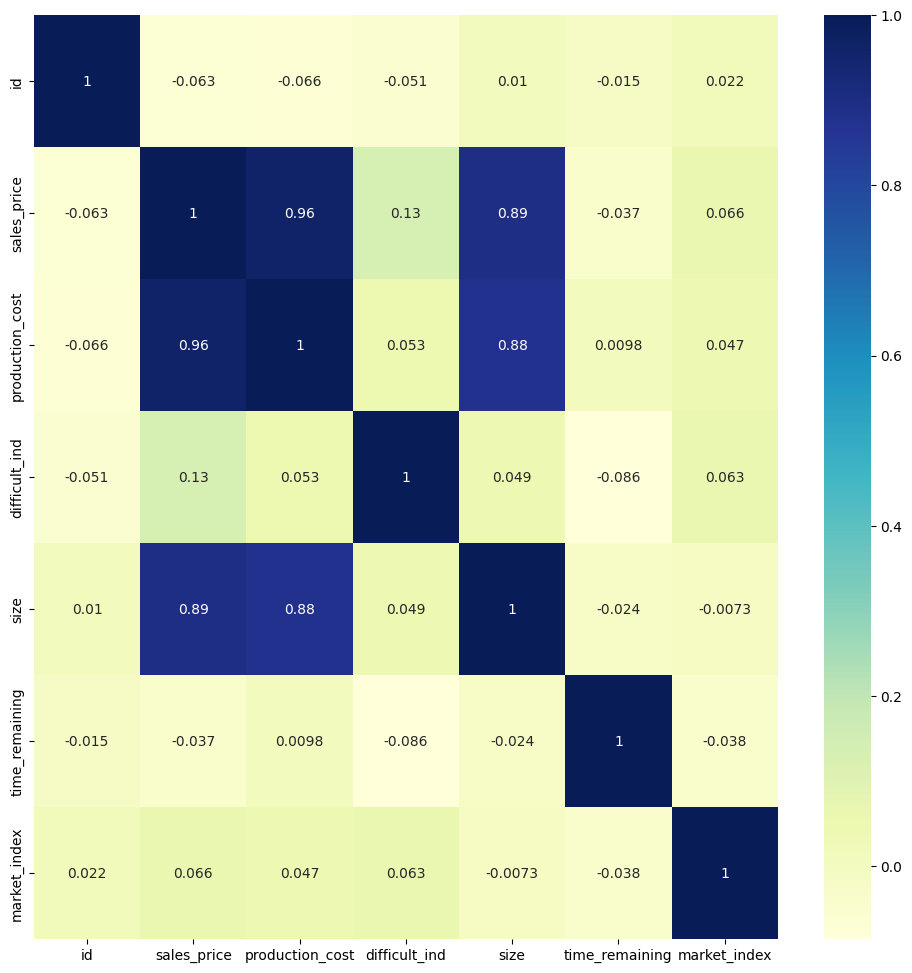

In [126]:
plt.figure(figsize=(12,12))
sns.heatmap(data=df_corr,
            cmap="YlGnBu",
            annot = True)
plt.show()

Modelos válidos encontrados (ordenados por R² ajustado):


,variables,R2_adj,AIC,pvalues
2,"production_cost, size",0.930342,2.673658e+06,"{'production_cost': 0.0, 'size': 0.0}"
0,"production_cost, time_remaining",0.920397,2.713364e+06,"{'production_cost': 0.0, 'time_remaining': 0.0}"
1,"production_cost, market_index",0.918644,2.719845e+06,"{'production_cost': 0.0, 'market_index': 0.0}"
5,"market_index, size",0.805747,2.978793e+06,"{'market_index': 0.0, 'size': 0.0}"
4,"time_remaining, size",0.800747,2.986354e+06,"{'time_remaining': 5.020093131208936e-79, 'siz..."
3,"time_remaining, market_index",0.005537,3.464670e+06,"{'time_remaining': 1.9885652405248064e-80, 'ma..."


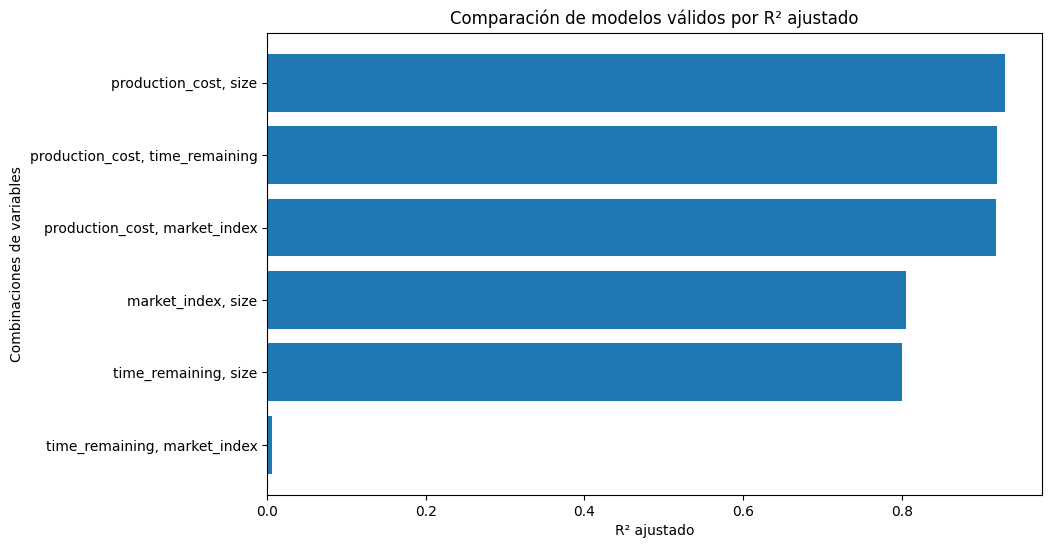

In [127]:
## Ejercicio 1: Selección automática del mejor modelo

import itertools
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Variables continuas consideradas
vars_cont = ["production_cost", "time_remaining", "market_index", "size"]

# Nivel de significancia
alpha = 0.10

# Guardamos resultados
resultados = []

# Probar todas las combinaciones de 3 variables
for combo in itertools.combinations(vars_cont, 2):
    formula = "sales_price ~ " + " + ".join(combo)
    modelo = smf.ols(formula, data=df).fit()
    
    # Revisamos p-valores (excluyendo el intercepto)
    pvalues = modelo.pvalues.drop("Intercept")
    
    # Validamos si todas las variables cumplen p ≤ 0.1
    if all(pvalues <= alpha):
        resultados.append({
            "variables": ", ".join(combo),
            "R2_adj": modelo.rsquared_adj,
            "AIC": modelo.aic,
            "pvalues": pvalues.to_dict()
        })
    
# Mostrar resultados ordenados por R² ajustado
if resultados:
    # Convertimos a DataFrame
    df_resultados = pd.DataFrame(resultados)
    
    # Ordenamos por R² ajustado
    df_resultados = df_resultados.sort_values(by="R2_adj", ascending=False)
    
    print("Modelos válidos encontrados (ordenados por R² ajustado):")
    display(df_resultados)
    
    # -----------------------------------------------------------
    # Visualización
    # -----------------------------------------------------------
    plt.figure(figsize=(10,6))
    plt.barh(df_resultados["variables"], df_resultados["R2_adj"])
    plt.xlabel("R² ajustado")
    plt.ylabel("Combinaciones de variables")
    plt.title("Comparación de modelos válidos por R² ajustado")
    plt.gca().invert_yaxis()  # El mejor modelo arriba
    plt.show()
else:
    print(" No se encontró ningún modelo válido con p ≤ 0.1 en todas las variables.")


In [128]:
# Separar el dataset

# Separar 80% para entrenamiento y 20% para prueba

train_df,test_df=train_test_split(df,test_size=0.2,random_state=42)

print(f"Tamaño entrenamiento: {train_df.shape[0]}")
print(f"Tamaño prueba: {test_df.shape[0]}")

Tamaño entrenamiento: 238023
Tamaño prueba: 59506


In [129]:
best_vars = ["production_cost", "size"]

formula_log = "np.log1p(sales_price) ~ " + " + ".join(best_vars)
modelo_log = smf.ols(formula_log, data=train_df).fit()
print(modelo_log.summary())



                              OLS Regression Results                             
Dep. Variable:     np.log1p(sales_price)   R-squared:                       0.842
Model:                               OLS   Adj. R-squared:                  0.842
Method:                    Least Squares   F-statistic:                 6.337e+05
Date:                   Sat, 01 Nov 2025   Prob (F-statistic):               0.00
Time:                           22:00:25   Log-Likelihood:                 6113.7
No. Observations:                 238023   AIC:                        -1.222e+04
Df Residuals:                     238020   BIC:                        -1.219e+04
Df Model:                              2                                         
Covariance Type:               nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept   

In [130]:
test_df["predicted_log_sales"] = modelo_log.predict(test_df)

# Convertir predicciones a escala original
test_df["predicted_sales"] = np.expm1(test_df["predicted_log_sales"])

#Evaluación del modelo
rmse = np.sqrt(mean_squared_error(test_df["sales_price"], test_df["predicted_sales"]))
r2 = r2_score(test_df["sales_price"], test_df["predicted_sales"])

print(f"\nEvaluación del modelo en test (escala original):")
print(f"RMSE: {rmse:.2f}")
print(f"R² en test: {r2:.4f}")


Evaluación del modelo en test (escala original):
RMSE: 70.73
R² en test: 0.2607


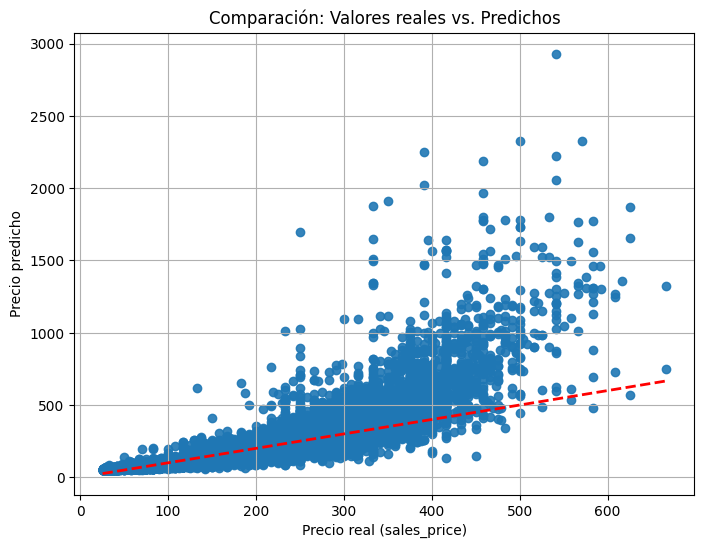

In [131]:
#Graficar 

plt.figure(figsize=(8,6))
plt.scatter(test_df["sales_price"], test_df["predicted_sales"], alpha=0.9)
plt.plot([test_df["sales_price"].min(), test_df["sales_price"].max()],
         [test_df["sales_price"].min(), test_df["sales_price"].max()],
         color="red", linestyle="--", linewidth=2)
plt.title("Comparación: Valores reales vs. Predichos")
plt.xlabel("Precio real (sales_price)")
plt.ylabel("Precio predicho")
plt.grid(True)
plt.show()





In [132]:
#modelo final con el dataset 

modelo_final_log = smf.ols(formula_log, data=df).fit()
print("\n Modelo final ajustado con log(sales_price):")
print(modelo_final_log.summary())


 Modelo final ajustado con log(sales_price):
                              OLS Regression Results                             
Dep. Variable:     np.log1p(sales_price)   R-squared:                       0.842
Model:                               OLS   Adj. R-squared:                  0.842
Method:                    Least Squares   F-statistic:                 7.903e+05
Date:                   Sat, 01 Nov 2025   Prob (F-statistic):               0.00
Time:                           22:00:25   Log-Likelihood:                 7206.8
No. Observations:                 297529   AIC:                        -1.441e+04
Df Residuals:                     297526   BIC:                        -1.438e+04
Df Model:                              2                                         
Covariance Type:               nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

# Conclusión

* production_cost y size son predictores directos del precio de venta.

* Mayor costo o mayor tamaño → generalmente mayor precio predicho.

* El modelo combina ambos efectos linealmente (en log si aplicaste log1p).

* La transformación logarítmica aplana los precios muy altos, pero la relación relativa sigue siendo la misma: precios suben con costo o tamaño.